# Startup Success Analysis and Prediction

In this notebook, we analyze the factors that influence startup success (defined as being acquired) versus closure.
We'll perform Exploratory Data Analysis (EDA) and train a Random Forest model to identify the most critical drivers of startup outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

## 1. Load Data and Initial Inspection

In [2]:
df = pd.read_csv("startup data.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Shape: 923 rows, 49 columns



,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


Let's look at missing values and data types.

In [3]:
print("--- Info ---")
print(df.info())
print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 
 1

## 2. Data Cleaning

Dropping unnecessary index and duplicate columns, and handling missing milestone ages.

In [4]:
columns_to_drop = ['Unnamed: 0', 'Unnamed: 6', 'state_code.1', 'object_id']
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

df_clean['age_first_milestone_year'] = df_clean['age_first_milestone_year'].fillna(0)
df_clean['age_last_milestone_year'] = df_clean['age_last_milestone_year'].fillna(0)

print(f"Cleaned Shape: {df_clean.shape}")

Cleaned Shape: (923, 45)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

/var/folders/t7/s42pwrz52637d6d8j28863pm0000gn/T/ipykernel_51825/3984233047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='status', palette=['#4CAF50', '#F44336'])


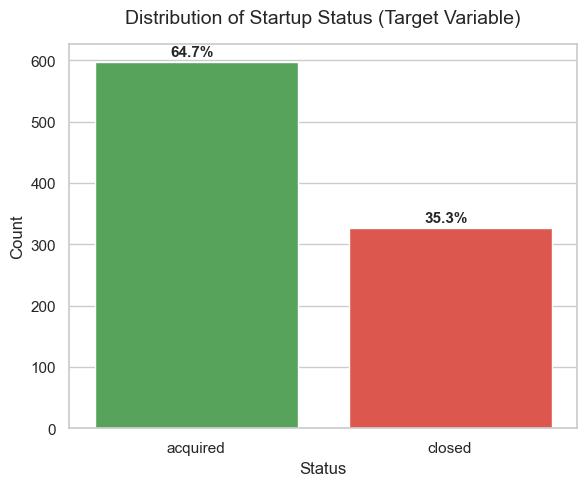

In [12]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df_clean, x='status', palette=['#4CAF50', '#F44336'])
plt.title('Distribution of Startup Status (Target Variable)', fontsize=14, pad=15)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + 10
    ax.annotate(percentage, (x_coord, y_coord), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 Geographic Distribution

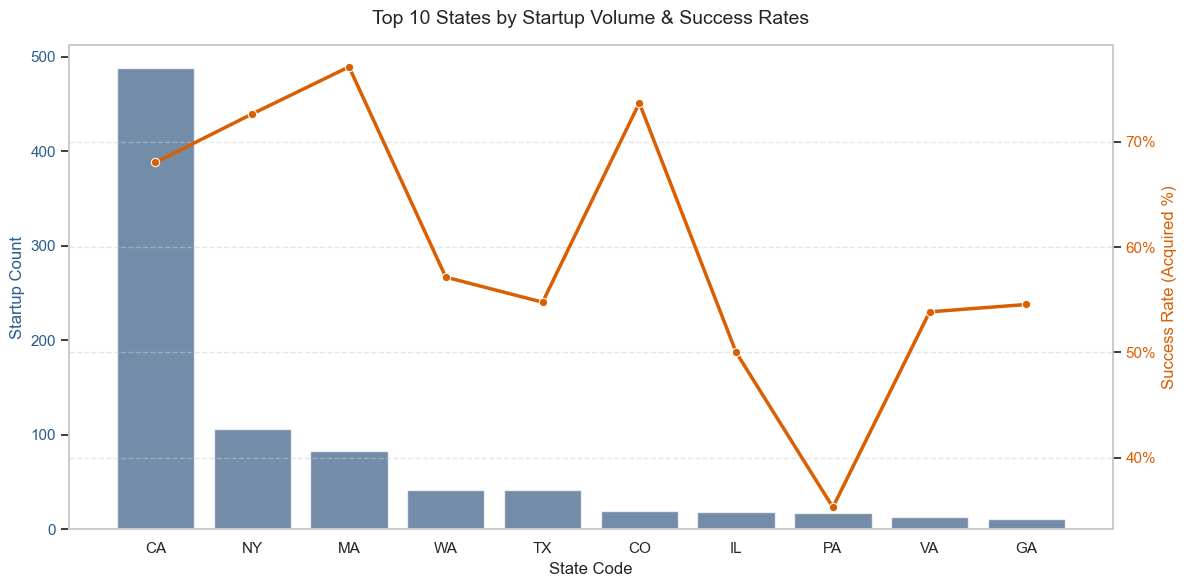

In [14]:
state_stats = df_clean.groupby('state_code')['labels'].agg(['count', 'mean']).reset_index()
state_stats = state_stats.rename(columns={'mean': 'success_rate'}).sort_values(by='count', ascending=False)

top_states = state_stats.head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#2b5c8f'
sns.barplot(data=top_states, x='state_code', y='count', ax=ax1, color=color, alpha=0.7)
ax1.set_title('Top 10 States by Startup Volume & Success Rates', fontsize=14, pad=15)
ax1.set_xlabel('State Code', fontsize=12)
ax1.set_ylabel('Startup Count', color=color, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(False)

ax2 = ax1.twinx()
color = '#d95f02'
sns.lineplot(data=top_states, x='state_code', y='success_rate', ax=ax2, color=color, marker='o', linewidth=2.5)
ax2.set_ylabel('Success Rate (Acquired %)', color=color, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3.3 Industry / Category Distribution

/var/folders/t7/s42pwrz52637d6d8j28863pm0000gn/T/ipykernel_51825/1015477406.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_cats, x='count', y='category_code', palette='viridis')


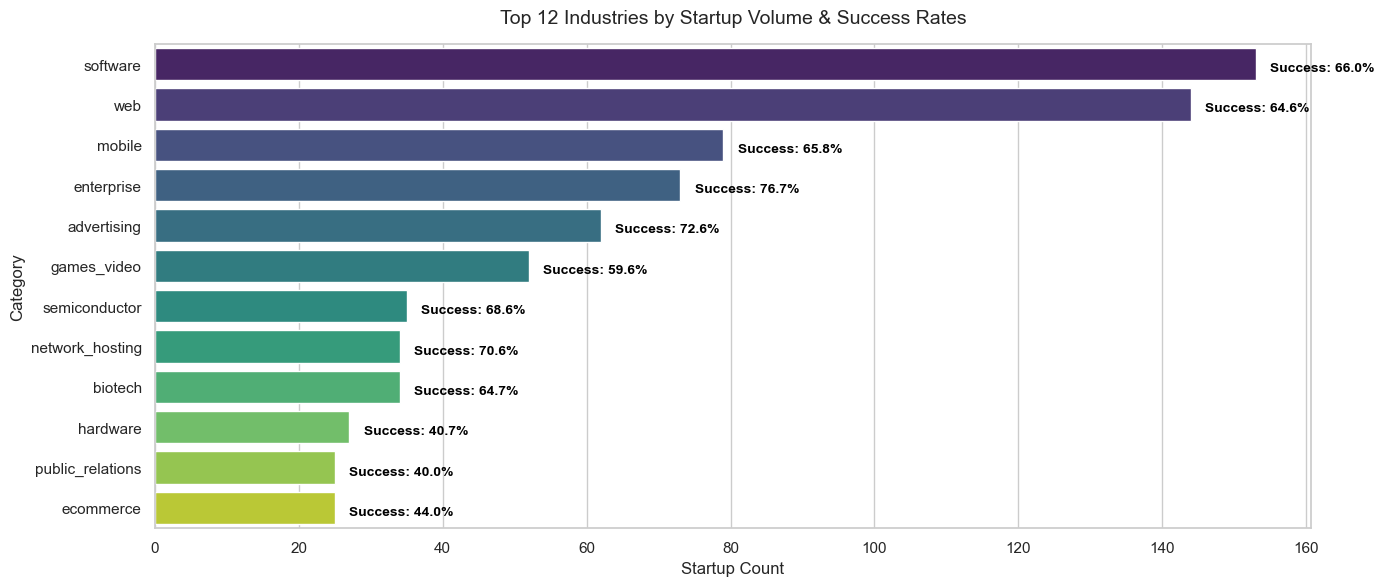

In [17]:
cat_stats = df_clean.groupby('category_code')['labels'].agg(['count', 'mean']).reset_index()
cat_stats = cat_stats.rename(columns={'mean': 'success_rate'}).sort_values(by='count', ascending=False)

top_cats = cat_stats.head(12)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=top_cats, x='count', y='category_code', palette='viridis')
plt.title('Top 12 Industries by Startup Volume & Success Rates', fontsize=14, pad=15)
plt.xlabel('Startup Count', fontsize=12)
plt.ylabel('Category', fontsize=12)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    success_rate = top_cats.iloc[i]['success_rate']
    ax.text(width + 2, p.get_y() + p.get_height()/2 + 0.1,
            f'Success: {success_rate:.1%}',
            ha="left", va="center", fontsize=10, color='black', fontweight='semibold')

plt.tight_layout()
plt.show()

### 3.4 Funding Analysis

Applying a log scale to total funding since the distribution is highly skewed.

/var/folders/t7/s42pwrz52637d6d8j28863pm0000gn/T/ipykernel_51825/3239132222.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_funding, x='status', y='log_funding_total_usd', palette=['#4CAF50', '#F44336'])


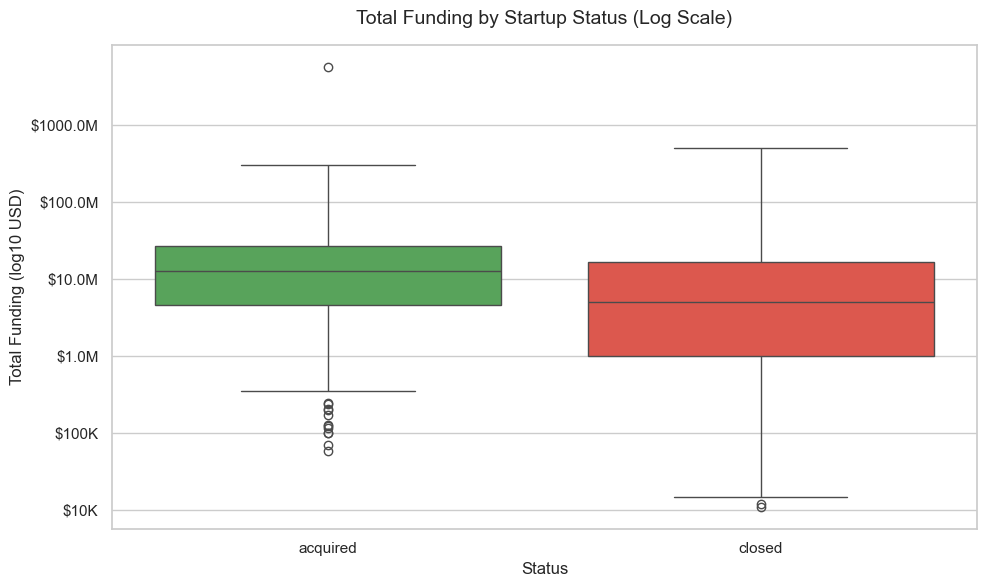

In [20]:
df_funding = df_clean[df_clean['funding_total_usd'] > 0].copy()
df_funding['log_funding_total_usd'] = np.log10(df_funding['funding_total_usd'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_funding, x='status', y='log_funding_total_usd', palette=['#4CAF50', '#F44336'])
plt.title('Total Funding by Startup Status (Log Scale)', fontsize=14, pad=15)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Total Funding (log10 USD)', fontsize=12)

ticks = range(4, 10)
plt.yticks(ticks, [f"${10**t/1e6:.1f}M" if t>=6 else f"${10**t/1e3:.0f}K" for t in ticks])

plt.tight_layout()
plt.show()

Looking at the distribution of funding rounds.

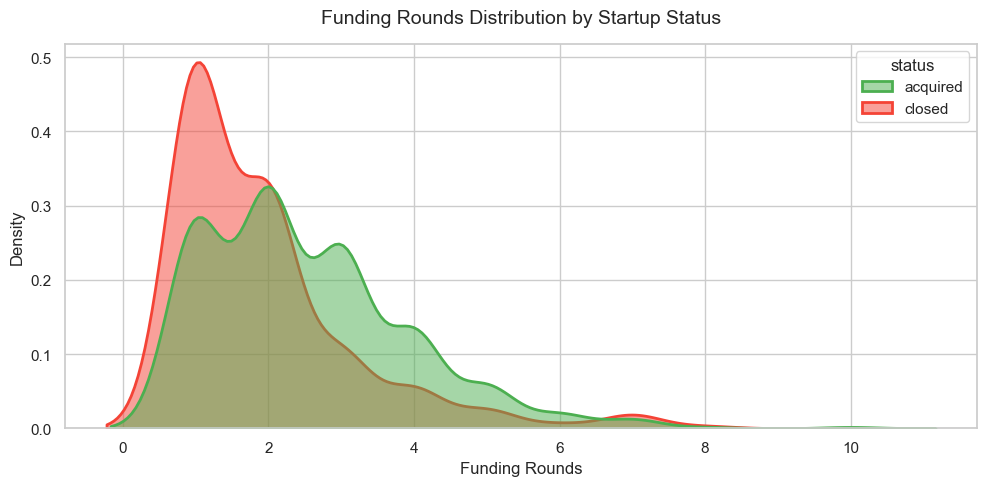

In [23]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_clean, x='funding_rounds', hue='status', fill=True, common_norm=False, palette=['#4CAF50', '#F44336'], alpha=0.5, linewidth=2)
plt.title('Funding Rounds Distribution by Startup Status', fontsize=14, pad=15)
plt.xlabel('Funding Rounds', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

### 3.5 Relationships and Milestones

/var/folders/t7/s42pwrz52637d6d8j28863pm0000gn/T/ipykernel_51825/4079962938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='status', y='relationships', ax=ax1, palette=['#4CAF50', '#F44336'], showfliers=False)
/var/folders/t7/s42pwrz52637d6d8j28863pm0000gn/T/ipykernel_51825/4079962938.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='status', y='milestones', ax=ax2, palette=['#4CAF50', '#F44336'])


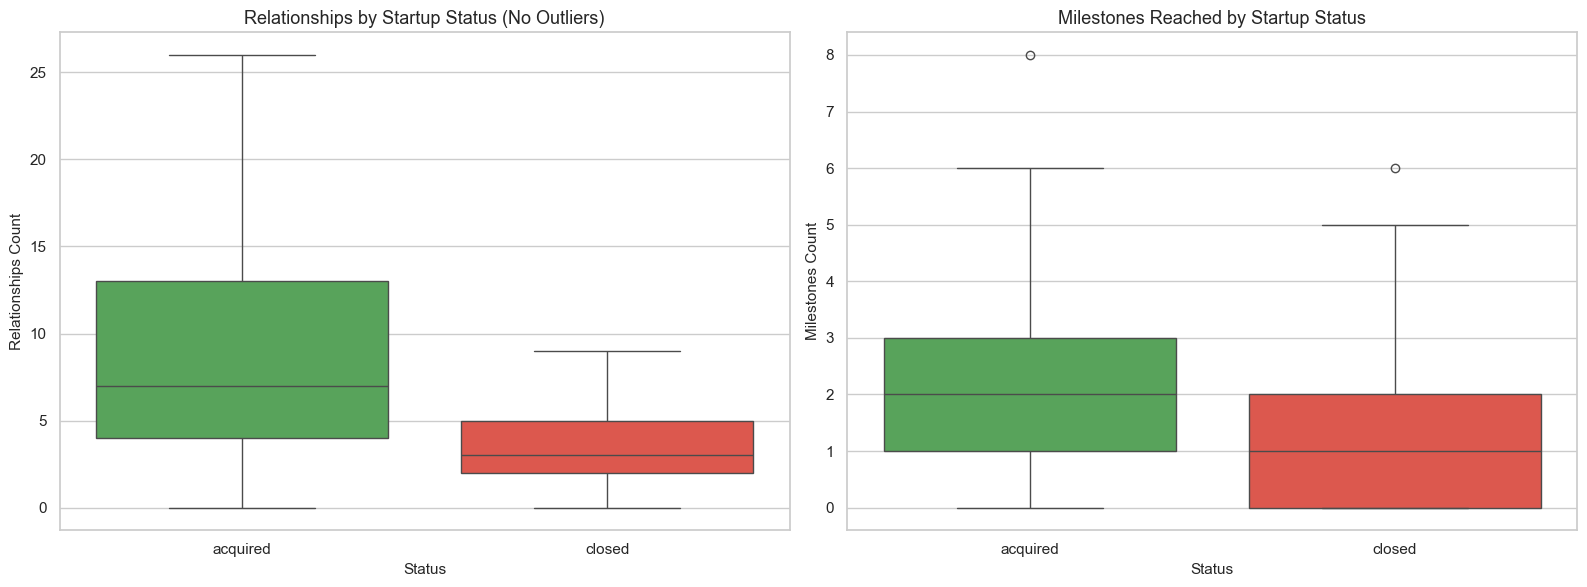

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_clean, x='status', y='relationships', ax=ax1, palette=['#4CAF50', '#F44336'], showfliers=False)
ax1.set_title('Relationships by Startup Status (No Outliers)', fontsize=13)
ax1.set_xlabel('Status', fontsize=11)
ax1.set_ylabel('Relationships Count', fontsize=11)

sns.boxplot(data=df_clean, x='status', y='milestones', ax=ax2, palette=['#4CAF50', '#F44336'])
ax2.set_title('Milestones Reached by Startup Status', fontsize=13)
ax2.set_xlabel('Status', fontsize=11)
ax2.set_ylabel('Milestones Count', fontsize=11)

plt.tight_layout()
plt.show()

### 3.6 Age at First Funding

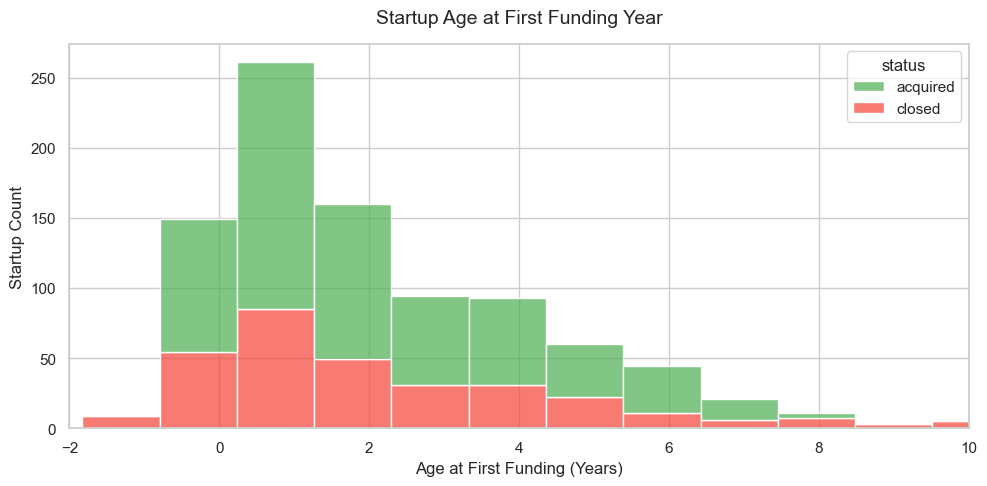

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='age_first_funding_year', hue='status', multiple='stack', bins=30, palette=['#4CAF50', '#F44336'], alpha=0.7)
plt.title('Startup Age at First Funding Year', fontsize=14, pad=15)
plt.xlabel('Age at First Funding (Years)', fontsize=12)
plt.ylabel('Startup Count', fontsize=12)
plt.xlim(-2, 10)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

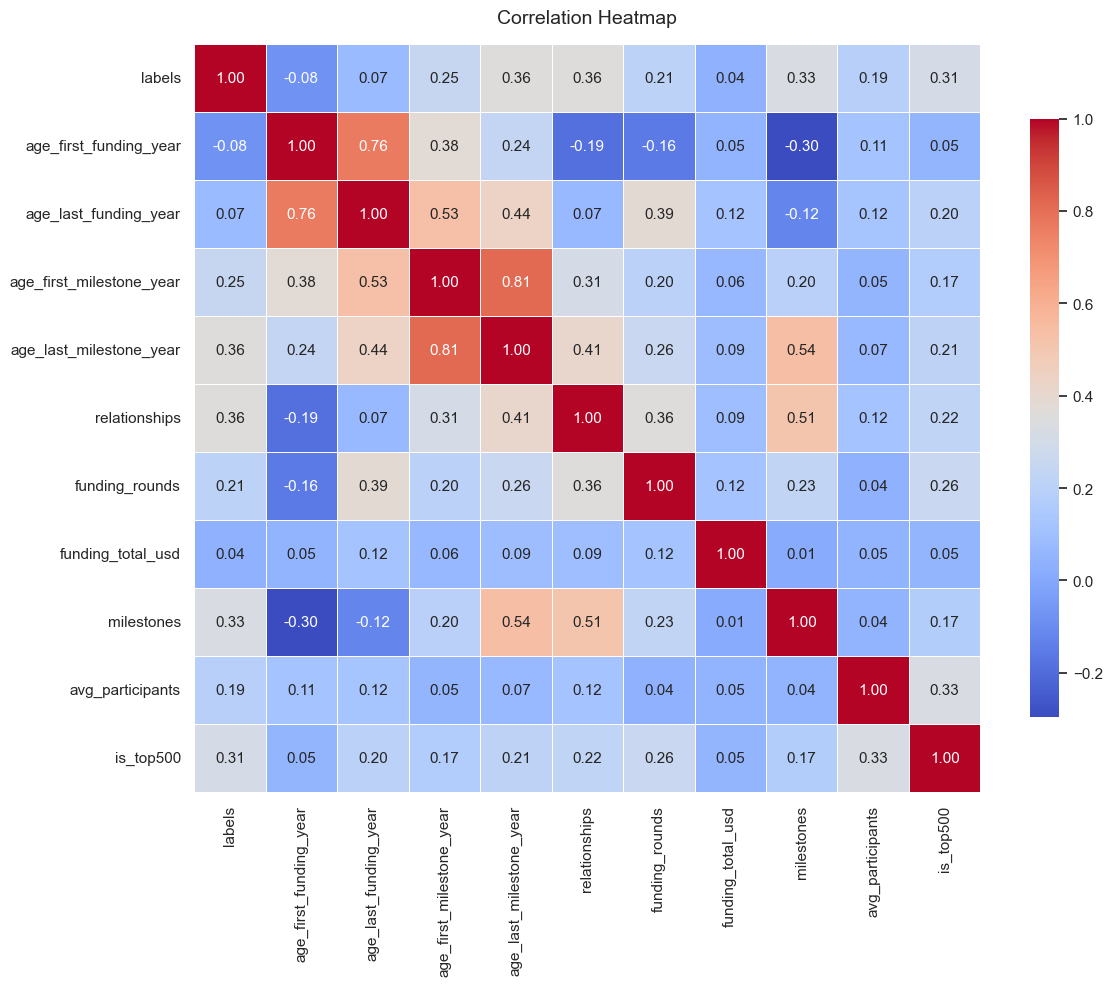

In [32]:
numeric_cols = [
    'labels', 'age_first_funding_year', 'age_last_funding_year', 
    'age_first_milestone_year', 'age_last_milestone_year', 
    'relationships', 'funding_rounds', 'funding_total_usd', 
    'milestones', 'avg_participants', 'is_top500'
]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Key correlation findings:
- **Relationships** has the strongest positive correlation with startup success (`labels`).
- **Milestones** reached and being in the **top 500** also show moderate positive correlation.

## 5. Machine Learning Modeling

Training a Random Forest model to predict status (acquired vs closed).

In [36]:
exclude_cols = ['name', 'status', 'labels', 'state_code', 'category_code', 'zip_code', 'city', 'id', 'founded_at', 'closed_at', 'first_funding_at', 'last_funding_at']
X = df_clean.drop(columns=exclude_cols, errors='ignore')
y = df_clean['labels']

print(f"Number of Features: {X.shape[1]}")
print("Features sample:", X.columns.tolist()[:10])

Number of Features: 33
Features sample: ['latitude', 'longitude', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones']


Train-test split (80-20).

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

Train size: 738 samples
Test size: 185 samples


Training the classifier.

--- Classification Report ---
              precision    recall  f1-score   support

      Closed       0.75      0.58      0.66        65
    Acquired       0.80      0.89      0.84       120

    accuracy                           0.78       185
   macro avg       0.77      0.74      0.75       185
weighted avg       0.78      0.78      0.78       185



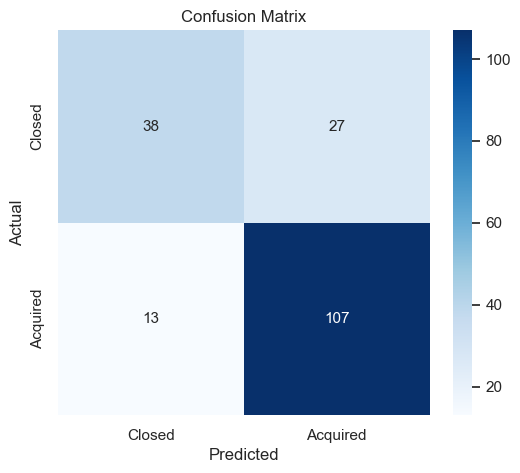

ROC-AUC Score: 0.8373


In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Closed', 'Acquired']))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
plt.title('Confusion Matrix', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

### 5.1 Feature Importances

/var/folders/t7/s42pwrz52637d6d8j28863pm0000gn/T/ipykernel_51825/3442772074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='crest')


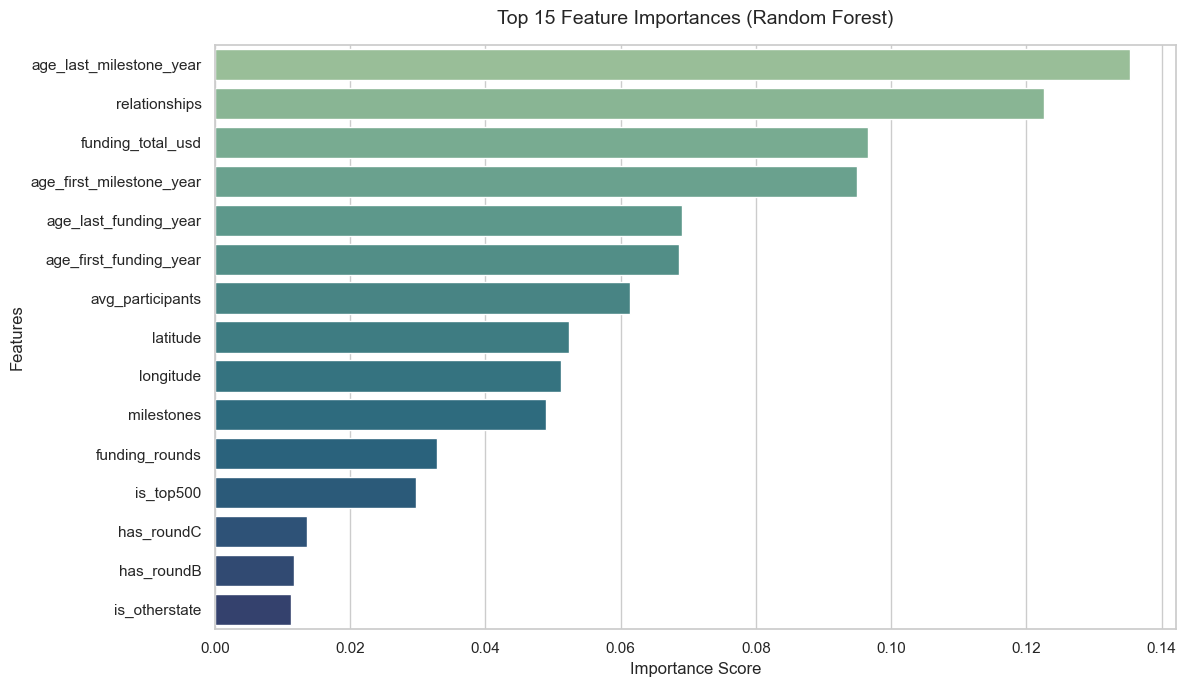

In [45]:
importances = rf_model.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

top_15_features = rf_importances.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='crest')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Key Takeaways

- **Network Influence:** The number of professional relationships is the strongest predictor of startup success. More connections link with higher acquisition rates.
- **Milestones Matter:** Setting and hitting milestones is highly indicative of viability.
- **Timing and Funding:** Raising early funding shows strong survival signals; raising capital early in the lifecycle correlates with positive exits.
- **Geography:** Traditional hubs (CA, MA, NY) remain leading locations in volume and success rates.